# Check CSV vs NetCDF track

Questo notebook legge il CSV e il NetCDF della track di Jolina, mostra struttura e campi, e verifica che i valori salvati nel NetCDF coincidano esattamente con quelli del CSV.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

csv_path = Path('/media/isacDisk2/demetra_output/jolina/tracking_inference_predictions_local.csv')
nc_path = Path('/media/isacDisk2/demetra_output/jolina/tracking_inference_predictions_local.nc')

csv_path, nc_path

(PosixPath('/media/isacDisk2/demetra_output/jolina/tracking_inference_predictions_local.csv'),
 PosixPath('/media/isacDisk2/demetra_output/jolina/tracking_inference_predictions_local.nc'))

In [11]:
csv_df = pd.read_csv(csv_path)
csv_df['datetime'] = pd.to_datetime(csv_df['datetime'])
csv_df = csv_df.sort_values('datetime').reset_index(drop=True)

ds = xr.open_dataset(nc_path, engine='h5netcdf')
nc_df = ds.to_dataframe().reset_index().rename(columns={'time': 'datetime'})
nc_df['datetime'] = pd.to_datetime(nc_df['datetime'])
nc_df = nc_df.sort_values('datetime').reset_index(drop=True)

print(f'CSV rows: {len(csv_df)}')
print(f'NetCDF rows: {len(nc_df)}')

CSV rows: 583
NetCDF rows: 583


In [12]:
print('CSV columns:', list(csv_df.columns))
print('NetCDF data variables:', list(ds.data_vars))
print('NetCDF coordinates:', list(ds.coords))
print('NetCDF global attrs:', dict(ds.attrs))

print()
print('CSV head:')
display(csv_df.head())

print()
print('Dataset summary:')
ds

CSV columns: ['datetime', 'has_cyclone', 'pred_lat', 'pred_lon']
NetCDF data variables: ['has_cyclone', 'pred_lat', 'pred_lon']
NetCDF coordinates: ['time']
NetCDF global attrs: {'title': 'Jolina local track', 'source': 'DeMeTra tracking inference local CSV', 'featureType': 'trajectory', 'history': 'Converted from CSV with csv_track_to_netcdf.py'}

CSV head:


,datetime,has_cyclone,pred_lat,pred_lon
0,2026-03-16 06:25:00,1,33.32,12.61
1,2026-03-16 06:30:00,1,33.36,12.64
2,2026-03-16 06:35:00,1,33.32,12.68
3,2026-03-16 06:40:00,1,33.36,12.68
4,2026-03-16 06:45:00,1,33.36,12.68



Dataset summary:


<xarray.Dataset>
Dimensions:      (time: 583)
Coordinates:
  * time         (time) datetime64[ns] 2026-03-16T06:25:00 ... 2026-03-18T06:...
Data variables:
    has_cyclone  (time) int64 1 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1
    pred_lat     (time) float64 33.32 33.36 33.32 33.36 ... 31.32 31.29 31.33
    pred_lon     (time) float64 12.61 12.64 12.68 12.68 ... 19.53 19.56 19.6
Attributes:
    title:        Jolina local track
    source:       DeMeTra tracking inference local CSV
    featureType:  trajectory
    history:      Converted from CSV with csv_track_to_netcdf.py

In [13]:
common_cols = [col for col in csv_df.columns if col in nc_df.columns]
comparison_rows = []

for col in common_cols:
    left = csv_df[col].to_numpy()
    right = nc_df[col].to_numpy()
    exact_equal = np.array_equal(left, right)
    comparison_rows.append({
        'column': col,
        'exact_equal': exact_equal,
        'csv_dtype': str(csv_df[col].dtype),
        'nc_dtype': str(nc_df[col].dtype),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

all_equal = comparison_df['exact_equal'].all()
print(f'All common columns exactly equal: {all_equal}')

,column,exact_equal,csv_dtype,nc_dtype
0,datetime,True,datetime64[ns],datetime64[ns]
1,has_cyclone,True,int64,int64
2,pred_lat,True,float64,float64
3,pred_lon,True,float64,float64


All common columns exactly equal: True


In [14]:
if not all_equal:
    for col in common_cols:
        left = csv_df[col].to_numpy()
        right = nc_df[col].to_numpy()
        if not np.array_equal(left, right):
            mismatch_idx = np.where(left != right)[0]
            print(f'First mismatches for {col}:', mismatch_idx[:10].tolist())
            display(pd.DataFrame({
                'csv': csv_df.loc[mismatch_idx[:10], col].to_list(),
                'nc': nc_df.loc[mismatch_idx[:10], col].to_list(),
            }, index=mismatch_idx[:10]))
else:
    print('No mismatches found.')

No mismatches found.


In [15]:
comparison_view = csv_df.rename(columns={
    'has_cyclone': 'has_cyclone_csv',
    'pred_lat': 'pred_lat_csv',
    'pred_lon': 'pred_lon_csv',
}).copy()

comparison_view['has_cyclone_nc'] = nc_df['has_cyclone']
comparison_view['pred_lat_nc'] = nc_df['pred_lat']
comparison_view['pred_lon_nc'] = nc_df['pred_lon']
comparison_view['lat_diff'] = comparison_view['pred_lat_csv'] - comparison_view['pred_lat_nc']
comparison_view['lon_diff'] = comparison_view['pred_lon_csv'] - comparison_view['pred_lon_nc']

comparison_view.head(10)

,datetime,has_cyclone_csv,pred_lat_csv,pred_lon_csv,has_cyclone_nc,pred_lat_nc,pred_lon_nc,lat_diff,lon_diff
0,2026-03-16 06:25:00,1,33.32,12.61,1,33.32,12.61,0.0,0.0
1,2026-03-16 06:30:00,1,33.36,12.64,1,33.36,12.64,0.0,0.0
2,2026-03-16 06:35:00,1,33.32,12.68,1,33.32,12.68,0.0,0.0
3,2026-03-16 06:40:00,1,33.36,12.68,1,33.36,12.68,0.0,0.0
4,2026-03-16 06:45:00,1,33.36,12.68,1,33.36,12.68,0.0,0.0
5,2026-03-16 06:50:00,1,33.36,12.71,1,33.36,12.71,0.0,0.0
6,2026-03-16 06:55:00,1,33.36,12.74,1,33.36,12.74,0.0,0.0
7,2026-03-16 07:00:00,1,33.36,12.74,1,33.36,12.74,0.0,0.0
8,2026-03-16 07:05:00,1,33.39,12.78,1,33.39,12.78,0.0,0.0
9,2026-03-16 07:10:00,1,33.36,12.81,1,33.36,12.81,0.0,0.0


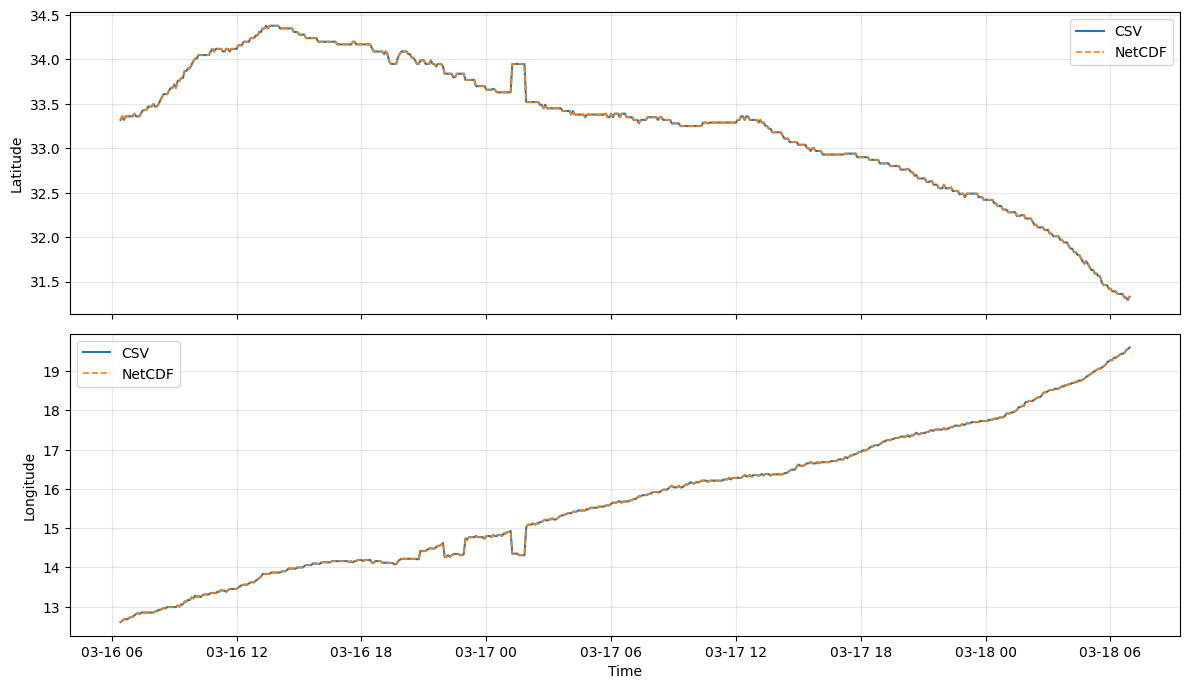

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(csv_df['datetime'], csv_df['pred_lat'], label='CSV', linewidth=1.5)
axes[0].plot(nc_df['datetime'], nc_df['pred_lat'], '--', label='NetCDF', linewidth=1.2)
axes[0].set_ylabel('Latitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(csv_df['datetime'], csv_df['pred_lon'], label='CSV', linewidth=1.5)
axes[1].plot(nc_df['datetime'], nc_df['pred_lon'], '--', label='NetCDF', linewidth=1.2)
axes[1].set_ylabel('Longitude')
axes[1].set_xlabel('Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

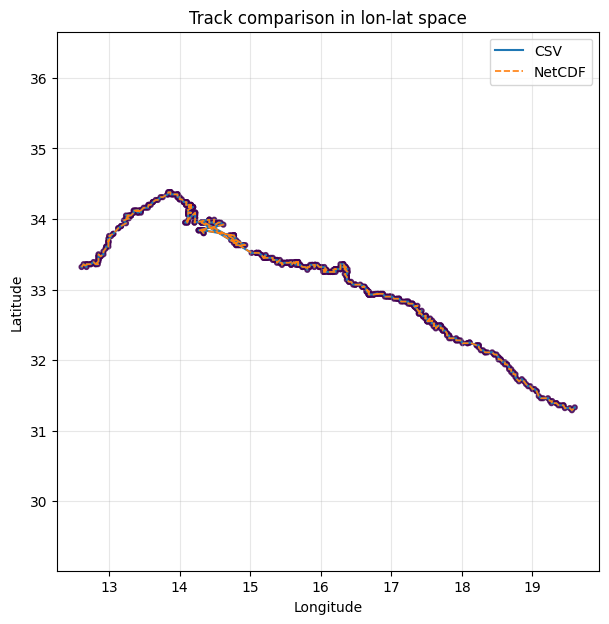

In [17]:
plt.figure(figsize=(7, 7))
plt.plot(csv_df['pred_lon'], csv_df['pred_lat'], label='CSV', linewidth=1.5)
plt.plot(nc_df['pred_lon'], nc_df['pred_lat'], '--', label='NetCDF', linewidth=1.2)
plt.scatter(csv_df['pred_lon'], csv_df['pred_lat'], c=csv_df['has_cyclone'], s=12, cmap='viridis', alpha=0.8)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Track comparison in lon-lat space')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')
plt.show()

In [18]:
ds.close()